Linear Fitting using SciKit Learn

Create X and Y variables and do a fit using scikitlearn.

Typically when doing fitting with scikitlearn, the first thing you will do is to import the type of model you want to use. In our case, we are importing a LinearRegression model. This type of model performs ordinary least squares fitting. You will first import the model, then you will create a model object. After creation, you will give data to the model and tell it to perform a fit. Your model can then be used to make predictions.


In [22]:
import pandas as pd

In [23]:
df = pd.read_csv("data/amino_acids_processed.csv")

In [24]:
X = df[["num_heavy"]]
Y = df[["molecular_weight"]]

Linear Fitting with SciKit Learn

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

#Fit a linear regression model
model = LinearRegression()
model.fit(X, Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


After the model created, we give it data and call the fit function. Then, the model will contain information about coefficients and an intercept.

In [26]:
print(f"The Co-efficients  are {model.coef_} and the intercept is {model.intercept_}")

The Co-efficients  are [[12.55841248]] and the intercept is [19.48134328]


Using the linear regression to make predictions

In [27]:
from sklearn.metrics import r2_score

#predict molecular weights using linear model
predicted_weight = model.predict(X)

print(f"Model coefficients (slope): {model.coef_[0][0]}")
print(f"Model intercept: {model.intercept_[0]}")

r2_score = (predicted_weight, Y)

Model coefficients (slope): 12.55841248303935
Model intercept: 19.481343283582063


Visualizing Results

Creating a scatter plot of predicted vs. actual (true) values to evaluate the model's performance.

In this type of plot, a perfect model to produce points that lie along a line with a slope of 1, which corresponds to the line ( y = x ). Points that fall below this diagonal line indicate that the model is under-predicting (i.e., the predicted values are less than the actual values), while points that fall above the line indicate that the model is over-predicting (i.e., the predicted values are greater than the actual values).

(68.612, 210.688, 68.43062347354137, 214.49690705563094)

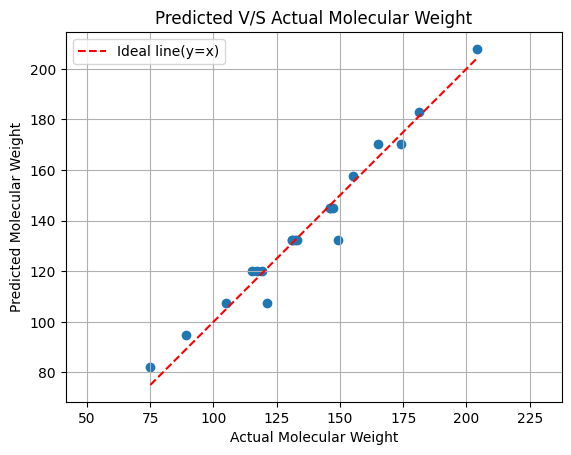

In [28]:
# Plot the results
y_values = Y.values
plt.scatter(y_values, predicted_weight)

plt.plot([min(y_values), max(y_values)], [min(y_values), max(y_values)], 'r--', label = 'Ideal line(y=x)')
plt.xlabel('Actual Molecular Weight')
plt.ylabel('Predicted Molecular Weight')
plt.title('Predicted V/S Actual Molecular Weight')
plt.legend()
plt.grid(True)
plt.axis('equal')

Model Validation - Train Test Split

Train test split divide data into two sets: a training set and a testing set. The training set is used to train the model, while the testing set is used to evaluate the model's performance.

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y)

In [30]:
#perform a train-test split using the training data only:
ttt_model = LinearRegression()
ttt_model.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


After performing our fit with the training data, use the "test" data to evaluate the model

In [31]:
y_pred = ttt_model.predict(X_test)

In [32]:
# Print the model coefficients
print(f"Model Coefficient (slope): {ttt_model.coef_[0][0]}")
print(f"model intercept: {ttt_model.intercept_[0]}")

r2_score = (y_pred, Y_test)

Model Coefficient (slope): 12.587330097087381
model intercept: 18.799498381876973


(68.612, 210.688, 68.44302750809061, 214.23642233009707)

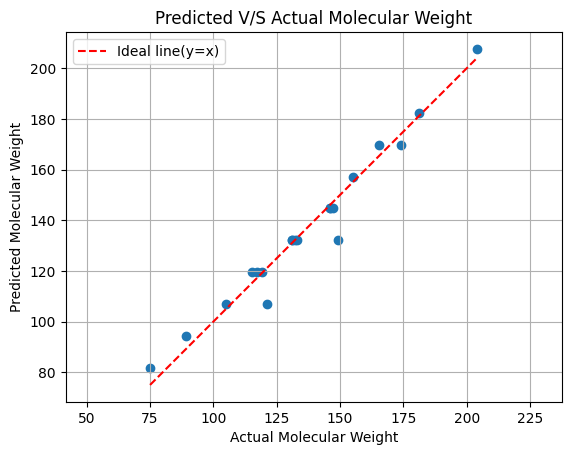

In [33]:
# Plot the results
y_value = Y.values
y_predict_all = ttt_model.predict(X)
plt.scatter(y_values, y_predict_all)

plt.plot([min(y_values), max(y_values)], [min(y_values), max(y_values)], 'r--', label = 'Ideal line(y=x)')
plt.xlabel('Actual Molecular Weight')
plt.ylabel('Predicted Molecular Weight')
plt.title('Predicted V/S Actual Molecular Weight')
plt.legend()
plt.grid(True)
plt.axis('equal')

Exercise: Using the periodic table dataset from the previous lesson, fit ionization energy vs. electronegativity with a linear model.

In [34]:
# provided 
periodic_df = pd.read_csv("data/PubChemElements_all.csv")
elements_to_fit = periodic_df.dropna(subset=['Electronegativity', 'IonizationEnergy'])

Slope: 3.5136225707140447
Intercept: 1.553785562548061
R^2: 0.8186646273660643


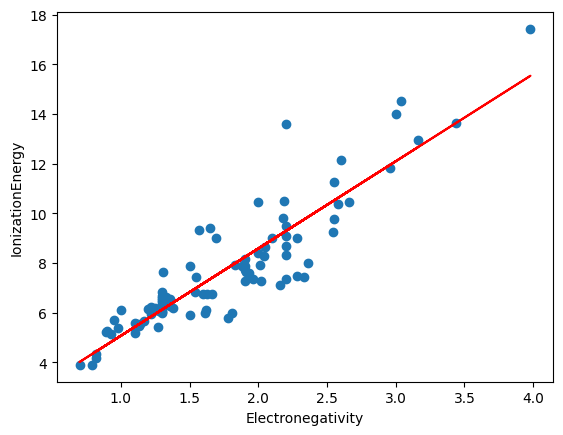

In [35]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

df = pd.read_csv("data/periodicdata_processed.csv")

fit_df = df[["Electronegativity", "IonizationEnergy"]].dropna()
X = fit_df[["Electronegativity"]]
y = fit_df["IonizationEnergy"]

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
print("R^2:", model.score(X, y))

plt.scatter(X, y)
plt.plot(X, y_pred, color="red")
plt.xlabel("Electronegativity")
plt.ylabel("IonizationEnergy")
plt.show()

Using RandomForestRegressor model for predictions

R^2: 0.9780395858729516
    IonizationEnergy  PredictedIonizationEnergy
0             13.598                   12.52412
2              5.392                    5.84903
3              9.323                    9.11155
4              8.298                    8.84118
5             11.260                   11.07215
6             14.534                   14.32127
7             13.618                   13.98463
8             17.423                   15.98115
10             5.139                    5.35626
11             7.646                    7.31832


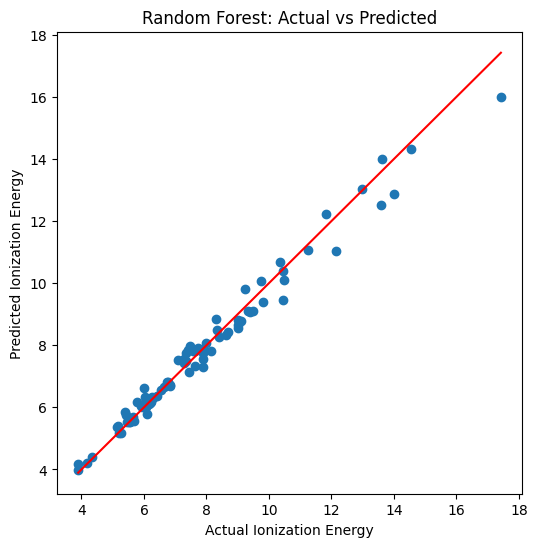

In [36]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# load data
periodic_df = pd.read_csv("data/periodicdata_processed.csv")

# keep only needed columns and remove missing values
fit_df = periodic_df[["AtomicRadius", "Electronegativity", "NOuter", "Rvdw", "IonizationEnergy"]].dropna()

# input features and target
X = fit_df[["AtomicRadius", "Electronegativity", "NOuter", "Rvdw"]]
#X = fit_df[["AtomicRadius"]]
y = fit_df["IonizationEnergy"]

# build and fit random forest model
model = RandomForestRegressor(random_state=42)
model.fit(X, y)

# predict
predictions = model.predict(X)

# R^2
print("R^2:", model.score(X, y))

# show first few actual vs predicted values
results = fit_df[["IonizationEnergy"]].copy()
results["PredictedIonizationEnergy"] = predictions
print(results.head(10))

# plot actual vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y, predictions)
plt.xlabel("Actual Ionization Energy")
plt.ylabel("Predicted Ionization Energy")
plt.title("Random Forest: Actual vs Predicted")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red")
plt.show()